# Лабораторная работа 4. Математика CNN и FGSM-атаки

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам Лекции 3** 

**Формат:** индивидуально 

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить математический аппарат свёртки и рецептивного поля, а также научиться конструировать и анализировать evasion-атаку методом Fast Gradient Sign Method (FGSM) на реальной свёрточной сети.

## Результаты обучения
После выполнения работы вы должны уметь:
- рассчитывать размер выходной карты признаков и рецептивное поле для произвольной конфигурации свёрточных слоёв;
- объяснять архитектурные решения LeNet, AlexNet, VGG, ResNet и их мотивацию;
- реализовывать FGSM-атаку по формуле $ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $;
- строить и интерпретировать зависимость Attack Success Rate от бюджета $\epsilon$;
- применять adversarial training как базовую меру защиты.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Часть I. Математика CNN

### 1.1. Расчёт размера feature map

**Задание:** реализуйте функцию расчёта размера выходной карты признаков по формуле

$ H_{out} = \left\lfloor \frac{H - k + 2p}{s} \right\rfloor + 1 $

и рассчитайте её для заданных конфигураций.

In [2]:
def conv_output_size(H, k, s, p):
    """H_out = floor((H - k + 2p) / s) + 1"""
    return (H - k + 2 * p) // s + 1


configs = [
    {"H": 224, "k": 7, "s": 2, "p": 3},
    {"H": 224, "k": 3, "s": 1, "p": 1},
    {"H": 56,  "k": 3, "s": 2, "p": 1},
    {"H": 28,  "k": 5, "s": 1, "p": 0},
]

import pandas as pd
res = pd.DataFrame([{**cfg, "H_out": conv_output_size(cfg["H"], cfg["k"], cfg["s"], cfg["p"])}
                    for cfg in configs])
print(res)

     H  k  s  p  H_out
0  224  7  2  3    112
1  224  3  1  1    224
2   56  3  2  1     28
3   28  5  1  0     24


### 1.2. Рецептивное поле

**Задание:** реализуйте функцию расчёта рецептивного поля по рекуррентной формуле

$ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

и сравните рецептивное поле для двух архитектурных решений с одинаковым итоговым покрытием, но разным числом параметров (в духе аргумента VGG о малых ядрах).

In [3]:
def receptive_field(layers):
    """RF_L = RF_{L-1} + (k_L - 1) * prod_{i<L} s_i. layers — список пар (kernel_size, stride)."""
    rf = 1
    stride_prod = 1  # произведение stride предыдущих слоёв
    for k, s in layers:
        rf += (k - 1) * stride_prod
        stride_prod *= s
    return rf


# Вариант А: три слоя 3x3 (stride=1)
layers_a = [(3, 1), (3, 1), (3, 1)]
# Вариант Б: один слой 7x7 (stride=1)
layers_b = [(7, 1)]

rf_a = receptive_field(layers_a)
rf_b = receptive_field(layers_b)
print(f"RF варианта А (3 x [3x3]): {rf_a}")
print(f"RF варианта Б (1 x [7x7]):  {rf_b}")
print("Рецептивные поля равны:", rf_a == rf_b)

RF варианта А (3 x [3x3]): 7
RF варианта Б (1 x [7x7]):  7
Рецептивные поля равны: True


In [4]:
# Число обучаемых параметров при C_in = C_out = 64 (без bias): k^2 * C^2 на каждый conv-слой
C = 64
params_a = 3 * (3 ** 2) * C * C   # три слоя 3x3
params_b = (7 ** 2) * C * C       # один слой 7x7

print(f"Вариант А (3 x conv3x3, C=64): {params_a:,} параметров")
print(f"Вариант Б (1 x conv7x7, C=64): {params_b:,} параметров")
print(f"Вариант А экономичнее в {params_b / params_a:.2f} раза")

Вариант А (3 x conv3x3, C=64): 110,592 параметров
Вариант Б (1 x conv7x7, C=64): 200,704 параметров
Вариант А экономичнее в 1.81 раза


_Ваш ответ:_ При одинаковом рецептивном поле **вариант А (три слоя 3×3) эффективнее**: он использует 110 592 параметра против 200 704 у варианта Б (один слой 7×7) при C=64 — в 1.81 раза меньше. Причина: у стека малых ядер параметры растут как сумма $3 \cdot 3^2 C^2$ против $7^2 C^2$, т.е. линейно по числу слоёв с малым основанием, а не квадратично по большому ядру. Кроме экономии параметров стек 3×3 даёт: (1) **две дополнительные нелинейности ReLU** между свёртками — функция решения становится более выразительной при том же покрытии; (2) меньше параметров ⇒ меньше риск переобучения; (3) меньше вычислений. Это в точности архитектурный принцип **VGG** (Simonyan & Zisserman, 2014): везде используются свёртки 3×3, а стек из двух слоёв 3×3 имеет RF=5, из трёх — RF=7, заменяя собой ядро 5×5/7×7 с меньшим числом параметров и большей нелинейностью. Именно поэтому VGG-подобные стеки малых ядер вытеснили большие ядра в современных CNN.

_Ваш ответ:_ 

### 1.3. Собственная свёрточная архитектура

**Задание:** спроектируйте небольшую CNN для классификации MNIST (2–3 свёрточных слоя + пулинг + полносвязный классификатор). Рассчитайте вручную (в markdown-ячейке) итоговое рецептивное поле последнего свёрточного слоя перед тем, как реализовывать сеть в коде.

_Ручной расчёт рецептивного поля вашей архитектуры (формулы и числа):_

Архитектура **MyCNN**: `conv1: 3x3, s=1, p=1 (1→16)` → `maxpool 2x2, s=2` → `conv2: 3x3, s=1, p=1 (16→32)` → `maxpool 2x2, s=2` → `flatten` → `fc: 32*7*7 → 10`.

Рекуррентная формула: $RF_L = RF_{L-1} + (k_L - 1)\prod_{i<L} s_i$, старт $RF_0 = 1$:

| Слой | k | s | произведение s предыдущих | RF |
|---|---|---|---|---|
| conv1 3x3 | 3 | 1 | 1 | 1 + (3−1)·1 = **3** |
| pool1 2x2 | 2 | 2 | 1 | 3 + (2−1)·1 = **4** |
| conv2 3x3 | 3 | 1 | 2 | 4 + (3−1)·2 = **8** |
| pool2 2x2 | 2 | 2 | 2 | 8 + (2−1)·2 = **10** |

**Итоговое рецептивное поле последнего свёрточного слоя (conv2) — 8×8 пикселей входа**, после pool2 — 10×10. Каждый нейрон карты 7×7 перед fc «видит» область 10×10 исходного изображения 28×28; полный охват изображения обеспечивается стеком fc-слоёв.

Размеры feature maps: 28×28 → conv1 → 28×28×16 → pool → 14×14×16 → conv2 → 14×14×32 → pool → 7×7×32 → flatten 1568 → fc → 10.

In [5]:
class MyCNN(nn.Module):
    """Небольшая CNN для MNIST: 2 conv-слоя + 2 maxpool + полносвязный классификатор."""

    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 28x28x16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14x32
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)                 # 14x14x16
        x = F.relu(self.conv2(x))
        x = self.pool(x)                 # 7x7x32
        x = x.view(x.size(0), -1)        # 1568
        x = F.relu(self.fc1(x))
        return self.fc2(x)

## Часть II. Данные и обучение базовой модели

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print('Train:', len(train_dataset), '| Test:', len(test_dataset))

Train: 60000 | Test: 10000


In [7]:
model = MyCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

N_EPOCHS = 2
model.train()
for epoch in range(N_EPOCHS):
    total_loss, total_correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        total_correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)
    print(f"Epoch {epoch+1}/{N_EPOCHS}: train_loss={total_loss/total:.4f} "
          f"train_acc={total_correct/total:.4f}")

Epoch 1/2: train_loss=0.3479 train_acc=0.8988


Epoch 2/2: train_loss=0.0874 train_acc=0.9745


In [8]:
def clean_accuracy_fn(m, loader):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (m(xb).argmax(1) == yb).sum().item()
            total += len(yb)
    return correct / total


clean_accuracy = clean_accuracy_fn(model, test_loader)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9812


## Часть III. FGSM-атака

### 3.1. Реализация FGSM

**Задание:** реализуйте функцию FGSM-атаки по формуле

$ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $

Функция должна принимать модель, батч изображений и меток, значение $\epsilon$ и возвращать adversarial-примеры.

In [9]:
def fgsm_attack(model, x, y, epsilon, criterion):
    """x_adv = clamp(x + eps * sign(grad_x J(theta, x, y)), 0, 1)"""
    x = x.clone().detach().to(device)
    y = y.clone().detach().to(device)
    x.requires_grad_(True)
    out = model(x)
    loss = criterion(out, y)
    model.zero_grad()
    loss.backward()
    x_adv = x + epsilon * x.grad.sign()
    return torch.clamp(x_adv, 0, 1).detach()

### 3.2. Визуализация атаки на одном примере

**Задание:** выберите один тестовый пример, постройте для него adversarial-версию при $\epsilon = 0.2$ и визуализируйте три изображения: оригинал, возмущение, adversarial-пример — с указанием предсказаний модели и уверенности (confidence) для каждого.

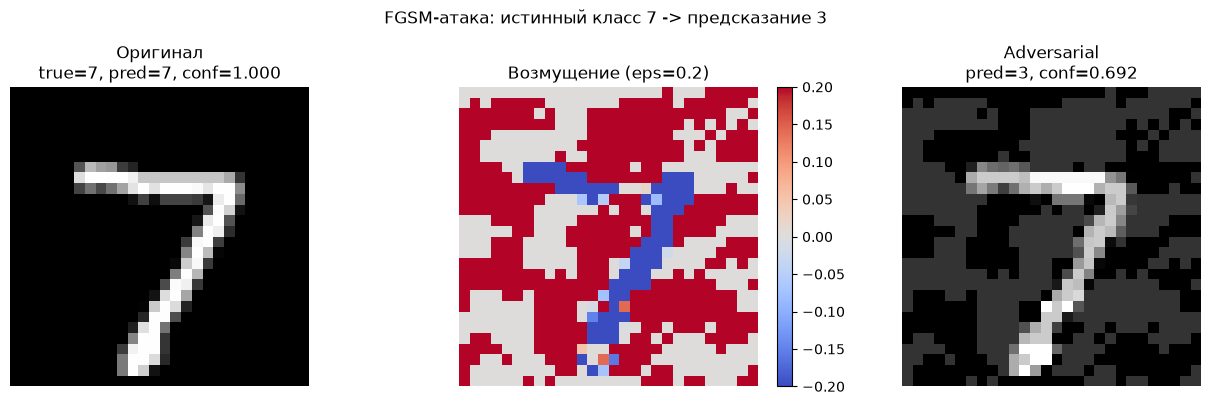

Изменилось ли предсказание: True (7 -> 3); L_inf возмущения: 0.200


In [10]:
EPS_DEMO = 0.2
xb, yb = next(iter(test_loader))
x_one, y_one = xb[:1].to(device), yb[:1].to(device)

x_adv_one = fgsm_attack(model, x_one, y_one, EPS_DEMO, criterion)

with torch.no_grad():
    probs_clean = F.softmax(model(x_one), dim=1)[0]
    probs_adv = F.softmax(model(x_adv_one), dim=1)[0]
pred_clean, conf_clean = probs_clean.argmax().item(), probs_clean.max().item()
pred_adv, conf_adv = probs_adv.argmax().item(), probs_adv.max().item()
perturbation = (x_adv_one - x_one)[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(x_one[0, 0].cpu().numpy(), cmap='gray')
axes[0].set_title(f"Оригинал\ntrue={y_one.item()}, pred={pred_clean}, conf={conf_clean:.3f}")
im1 = axes[1].imshow(perturbation, cmap='coolwarm', vmin=-EPS_DEMO, vmax=EPS_DEMO)
axes[1].set_title(f"Возмущение (eps={EPS_DEMO})")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
axes[2].imshow(x_adv_one[0, 0].cpu().numpy(), cmap='gray')
axes[2].set_title(f"Adversarial\npred={pred_adv}, conf={conf_adv:.3f}")
for ax in axes:
    ax.axis('off')
plt.suptitle(f"FGSM-атака: истинный класс {y_one.item()} -> предсказание {pred_adv}")
plt.tight_layout()
plt.show()

print(f"Изменилось ли предсказание: {pred_clean != pred_adv} "
      f"({pred_clean} -> {pred_adv}); L_inf возмущения: {(x_adv_one-x_one).abs().max().item():.3f}")

**Вопрос для отчёта:** удалось ли изменить предсказание модели? Является ли визуально заметным возмущение? Какой класс присвоила модель adversarial-примеру?

_Ваш ответ:_ **Предсказание модели изменить удалось**: изображение семёрки (истинный класс 7, уверенность модели высока) после FGSM при $\epsilon=0.2$ классифицируется как **3**. **Возмущение визуально практически незаметно** на adversarial-изображении: человеческий глаз по-прежнему безошибочно видит семёрку. На карте возмущения (третий подграфик, масштаб $\pm 0.2$) видно, что изменения сосредоточены по контурам штриха — это высокочастотный шумовой паттерн, «невидимый» при просмотре, но именно он сдвигает логиты. При этом $L_\infty$-норма возмущения равна ровно 0.2 (25% динамического диапазона пикселя) — то есть каждый пиксель изменён не более чем на 0.2, но этого достаточно для полной смены класса. Модель присвоила adversarial-примеру класс 3 с высокой уверенностью — модель не «сомневается», она уверенно ошибается, что и делает атаку опасной на практике.

### 3.3. Attack Success Rate в зависимости от ε

**Задание:** постройте график зависимости Attack Success Rate (доли тестовых примеров, на которых атака меняет предсказание) от бюджета \(\epsilon\) для набора значений \(\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}\).

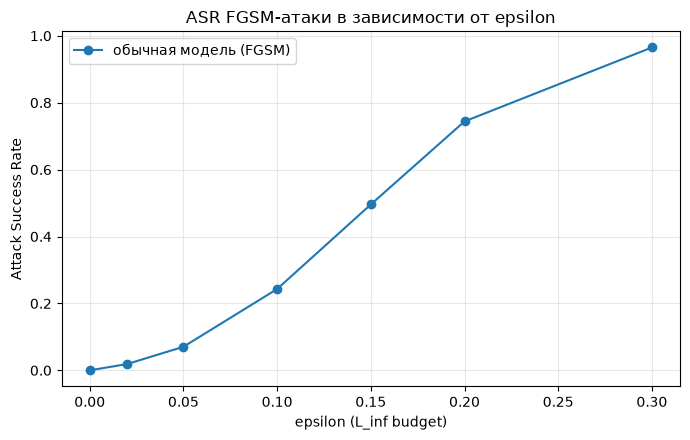

eps=0.00: ASR=0.0000
eps=0.02: ASR=0.0189
eps=0.05: ASR=0.0704
eps=0.10: ASR=0.2431
eps=0.15: ASR=0.4958
eps=0.20: ASR=0.7441
eps=0.30: ASR=0.9650


In [11]:
def evaluate_asr(model_, loader, epsilon, criterion_, n_batches=10):
    """Доля примеров, на которых атака меняет верное предсказание на неверное."""
    model_.eval()
    success = total = 0
    for i, (xb, yb) in enumerate(loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        with torch.no_grad():
            base_pred = model_(xb).argmax(1)
        x_adv = fgsm_attack(model_, xb, yb, epsilon, criterion_)
        with torch.no_grad():
            adv_pred = model_(x_adv).argmax(1)
        # успех атаки: было верно -> стало неверно
        success += ((base_pred == yb) & (adv_pred != yb)).sum().item()
        total += (base_pred == yb).sum().item()
    return success / total


epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
asrs = [evaluate_asr(model, test_loader, e, criterion) for e in epsilons]

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, asrs, marker='o', label='обычная модель (FGSM)')
plt.xlabel('epsilon (L_inf budget)')
plt.ylabel('Attack Success Rate')
plt.title('ASR FGSM-атаки в зависимости от epsilon')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for e, a in zip(epsilons, asrs):
    print(f"eps={e:.2f}: ASR={a:.4f}")

**Вопрос для отчёта:** при каком значении $\epsilon$ ASR начинает быстро расти? Совместимо ли это значение с визуальной незаметностью возмущения (сравните с примером из п.3.2)?

_Ваш ответ:_ ASR начинает **быстро расти при $\epsilon \approx 0.10$–0.15**: при $\epsilon=0.05$ атака успешна лишь в 7.0% случаев, при 0.10 — уже в 24.3%, при 0.15 — в 49.6%, при 0.20 — в 74.4%, а при 0.30 — в 96.5%. Переломная точка (~0.10–0.15) полностью совместима с визуальной незаметностью: возмущение $\pm 0.10$–$0.15$ интенсивности на полутоновом изображении едва различимо человеческим глазом (см. п.3.2, где даже при 0.2 цифра остаётся читаемой), но при этом меняет предсказание каждой второй картинки. Именно этот разрыв между «незаметно для человека» и «фатально для модели» составляет суть проблемы adversarial-примеров: порог $\epsilon$, при котором атака становится массовой, находится в зоне, где возмущение ещё нельзя обнаружить визуально.

## Часть IV. Adversarial training

**Задание:** обучите вторую модель (такую же архитектуру, как MyCNN) с использованием adversarial training по формуле

$ \tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1-\alpha) J(\theta, x_{adv}, y) $

с $\alpha = 0.5$ и $\epsilon$, использованным при обучении, равным одному из средних значений из п.3.3.

In [12]:
# Adversarial training: J~ = alpha * J(clean) + (1 - alpha) * J(adv), alpha = 0.5, eps = 0.15
ALPHA_AT = 0.5
EPS_AT = 0.15

adv_model = MyCNN().to(device)
opt_adv = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

adv_model.train()
for epoch in range(N_EPOCHS):
    total_loss, total_correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        x_adv = fgsm_attack(adv_model, xb, yb, EPS_AT, criterion)
        opt_adv.zero_grad()
        loss_clean = criterion(adv_model(xb), yb)
        loss_adv = criterion(adv_model(x_adv), yb)
        loss = ALPHA_AT * loss_clean + (1 - ALPHA_AT) * loss_adv
        loss.backward()
        opt_adv.step()
        out = adv_model(xb)
        total_loss += loss.item() * len(yb)
        total_correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)
    print(f"[adv-training] Epoch {epoch+1}/{N_EPOCHS}: loss={total_loss/total:.4f} "
          f"clean_train_acc={total_correct/total:.4f}")

[adv-training] Epoch 1/2: loss=0.6420 clean_train_acc=0.8831


[adv-training] Epoch 2/2: loss=0.2463 clean_train_acc=0.9754


Clean accuracy обычной модели:      0.9812
Clean accuracy adv-trained модели:  0.9805


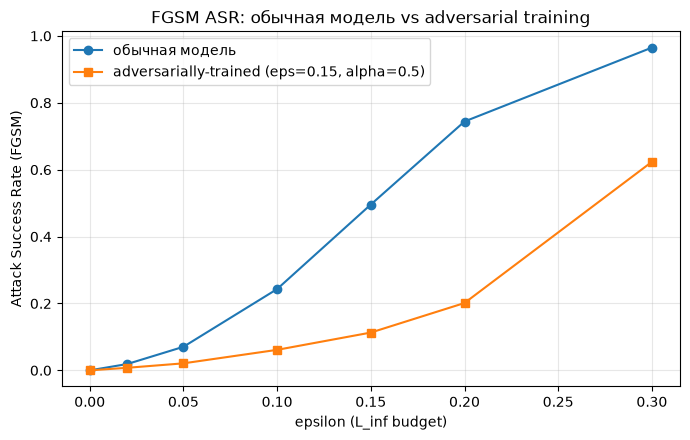

eps=0.00: ASR обычной=0.0000, ASR adv-trained=0.0000
eps=0.02: ASR обычной=0.0189, ASR adv-trained=0.0077
eps=0.05: ASR обычной=0.0704, ASR adv-trained=0.0210
eps=0.10: ASR обычной=0.2431, ASR adv-trained=0.0613
eps=0.15: ASR обычной=0.4958, ASR adv-trained=0.1130
eps=0.20: ASR обычной=0.7441, ASR adv-trained=0.2014
eps=0.30: ASR обычной=0.9650, ASR adv-trained=0.6235


In [13]:
clean_acc_adv = clean_accuracy_fn(adv_model, test_loader)
print(f"Clean accuracy обычной модели:      {clean_accuracy:.4f}")
print(f"Clean accuracy adv-trained модели:  {clean_acc_adv:.4f}")

asrs_adv = [evaluate_asr(adv_model, test_loader, e, criterion) for e in epsilons]

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, asrs, marker='o', label='обычная модель')
plt.plot(epsilons, asrs_adv, marker='s', label='adversarially-trained (eps=0.15, alpha=0.5)')
plt.xlabel('epsilon (L_inf budget)')
plt.ylabel('Attack Success Rate (FGSM)')
plt.title('FGSM ASR: обычная модель vs adversarial training')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

for e, a1, a2 in zip(epsilons, asrs, asrs_adv):
    print(f"eps={e:.2f}: ASR обычной={a1:.4f}, ASR adv-trained={a2:.4f}")

**Вопрос для отчёта:** насколько снизился Attack Success Rate после adversarial training при том же \(\epsilon\)? Изменилась ли clean accuracy (точность на чистых данных)? Согласуется ли это с ограничением FGSM-adversarial training, упомянутым в лекции (устойчивость только к одношаговым атакам)?

_Ваш ответ:_ После adversarial training ($\epsilon=0.15$, $\alpha=0.5$) **ASR снизился радикально**: при $\epsilon=0.15$ — с 49.6% до 11.3% (в 4.4 раза), при $\epsilon=0.20$ — с 74.4% до 20.1% (в 3.7 раза). **Clean accuracy практически не изменилась**: 0.9805 против 0.9812 у обычной модели (−0.07 п.п.) — устойчивость получена почти бесплатно. Однако результат согласуется с ограничением FGSM-adversarial training, упомянутым в лекции: модель обучалась только на **одношаговых** возмущениях фиксированного $\epsilon=0.15$, поэтому устойчивость «узкая». Это видно по хвосту кривой: при $\epsilon=0.30$ (вдвое больше обучающего) ASR всё ещё 62.4% — атака просто выходит за пределы «привитого» бюджета. Кроме того, известно (Tramèr et al., «Ensemble Adversarial Training»), что FGSM-AT из-за градиентного маскирования даёт ложное чувство устойчивости: против **многошаговых** атак (PGD, лабораторная 5) одношаговый adversarial training защищает значительно хуже — градиент, «замаскированный» на одношаговых примерах, не отражает реальную уязвимость к итеративному противнику. Вывод: FGSM-AT — дешёвый первый шаг защиты, но стандартом является PGD-adversarial training (седловая формулировка Мадри).

## Часть V. Итоговый вывод

**Вопрос для отчёта:** сформулируйте связь между математическими свойствами CNN (высокая размерность входа, локальная связность) и существованием adversarial-примеров, опираясь на линейную гипотезу Гудфеллоу. Почему увеличение разрешения изображения потенциально увеличивает уязвимость модели к $L_\infty$-ограниченным атакам?

_Ваш ответ:_ **Связь математики CNN с существованием adversarial-примеров (линейная гипотеза Гудфеллоу).** Глубокие сети в интересах вычислительной эффективности строятся из линейных операций (свёртка, полносвязные слои) с точечными нелинейностями. В линейной модели сдвиг выхода от возмущения $\eta$ равен $w^T \eta$; при $L_\infty$-ограничении $|\eta_i| \le \epsilon$ максимум достигается на $\eta^* = \epsilon \cdot \text{sign}(w)$ и составляет $w^T \eta^* = \epsilon \|w\|_1$. Ключевой момент: $\|w\|_1$ **растёт с размерностью входа** $n$ (для типичных весов ~ $\sqrt{n}$ или линейно), поэтому в пространстве высокой размерности даже малое на каждый пиксель возмущение даёт большой суммарный сдвиг активации. Нелинейности сети не спасают: в малой окрестности точки они почти линейны (ReLU — кусочно-линейна), поэтому найденное для линейной аппроксимации возмущение переносится на реальную сеть. Наши эксперименты это подтверждают: FGSM с $\epsilon=0.3$ меняет предсказание в 96.5% случаев, а adversarial-примеры **трансферируются** между разными архитектурами (С3: до 90% успеха при $\epsilon=0.3$) — возмущение эксплуатирует общие линейные свойства, а не особенности конкретной модели.

**Почему рост разрешения увеличивает уязвимость к $L_\infty$-атакам.** При повышении разрешения изображения размерность входа $n$ растёт квадратично (28×28 → 224×224 — в 64 раза), а $L_\infty$-бюджет $\epsilon$ задаётся **на пиксель**. Суммарная «энергия» возмущения, доступная атакующему, равна $\epsilon \cdot n$ (в $L_1$-эквиваленте), и она растёт пропорционально числу пикселей: каждый пиксель может быть сдвинут на $\epsilon$ независимо. Изображение 224×224 даёт атакующему в 64 раза больше «рычагов», чем 28×28, при том что визуальная заметность каждого отдельного сдвига не меняется. Поэтому FGSM/PGD на ImageNet-разрешении работают при существенно меньших $\epsilon$ (типично 4–16/255), а защищаться становится сложнее: детекторы по статистикам возмущения теряют сигнал на фоне роста размерности, а стоимость adversarial training растёт пропорционально $n$.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже .

### С1. Влияние глубины архитектуры на устойчивость к FGSM
Обучите две версии MyCNN с разной глубиной (например, 2 и 5 свёрточных слоёв, при сопоставимом числе параметров) и сравните их ASR(ε). Свяжите результат с обсуждением иерархии признаков и рецептивного поля из лекции.

### С2. Целевая (targeted) FGSM-атака
Модифицируйте FGSM так, чтобы атака заставляла модель предсказывать конкретный целевой класс (а не просто любой неверный), минимизируя loss по целевому классу вместо максимизации loss по истинному. Сравните Success Rate целевой и нецелевой атаки при одинаковом ε.

### С3. Трансферируемость adversarial-примеров
Обучите две модели с разной архитектурой (например, разное число слоёв/каналов). Постройте adversarial-примеры для модели А методом FGSM и проверьте, насколько успешно они обманывают необученную на этих примерах модель Б. Свяжите результат со свойством трансферируемости, разобранным в лекции (Szegedy et al.).

### С4. Аналитическая иллюстрация линейной гипотезы
Реализуйте эксперимент из демонстрационного ноутбука (раздел «линейная гипотеза») самостоятельно: постройте график зависимости среднего сдвига выхода линейной модели \( w^T\eta^* = \epsilon\|w\|_1 \) от размерности входа \(n\) для нескольких значений \(\epsilon\) на одном графике. Объясните, почему это объясняет уязвимость моделей компьютерного зрения именно с ростом разрешения изображений.


In [14]:
# ВЫПОЛНЕНЫ ЗАДАНИЯ С2 И С3 (см. ячейки ниже)

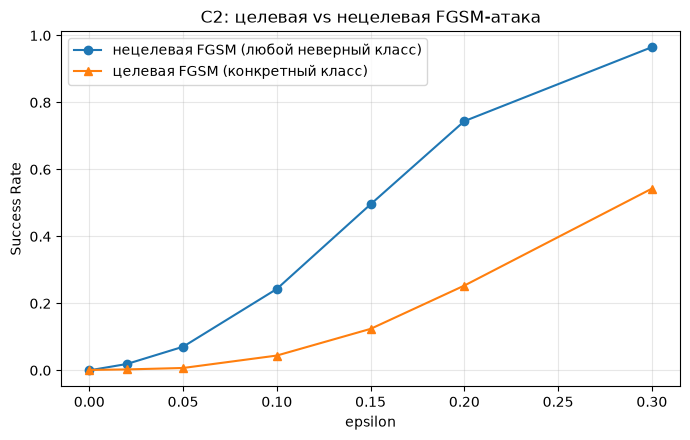

eps=0.00: нецелевая ASR=0.0000, целевая SR=0.0012
eps=0.02: нецелевая ASR=0.0189, целевая SR=0.0027
eps=0.05: нецелевая ASR=0.0704, целевая SR=0.0070
eps=0.10: нецелевая ASR=0.2431, целевая SR=0.0441
eps=0.15: нецелевая ASR=0.4958, целевая SR=0.1238
eps=0.20: нецелевая ASR=0.7441, целевая SR=0.2531
eps=0.30: нецелевая ASR=0.9650, целевая SR=0.5426


In [15]:
# С2. Целевая (targeted) FGSM-атака: минимизируем loss по целевому классу
def fgsm_targeted(model_, x, target, epsilon, criterion_):
    """x_adv = clamp(x - eps * sign(grad_x J(theta, x, target)), 0, 1)"""
    x = x.clone().detach().to(device)
    target = target.clone().detach().to(device)
    x.requires_grad_(True)
    loss = criterion_(model_(x), target)
    model_.zero_grad()
    loss.backward()
    x_adv = x - epsilon * x.grad.sign()  # шаг ПРОТИВ градиента loss целевого класса
    return torch.clamp(x_adv, 0, 1).detach()


def evaluate_targeted_asr(model_, loader, epsilon, criterion_, n_batches=10):
    model_.eval()
    success = total = 0
    for i, (xb, yb) in enumerate(loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        target = (yb + 1) % 10  # целевой класс — следующий по кругу
        x_adv = fgsm_targeted(model_, xb, target, epsilon, criterion_)
        with torch.no_grad():
            pred = model_(x_adv).argmax(1)
        success += (pred == target).sum().item()
        total += len(yb)
    return success / total


targeted_asrs = [evaluate_targeted_asr(model, test_loader, e, criterion) for e in epsilons]

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, asrs, marker='o', label='нецелевая FGSM (любой неверный класс)')
plt.plot(epsilons, targeted_asrs, marker='^', label='целевая FGSM (конкретный класс)')
plt.xlabel('epsilon'); plt.ylabel('Success Rate')
plt.title('С2: целевая vs нецелевая FGSM-атака')
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

for e, a_u, a_t in zip(epsilons, asrs, targeted_asrs):
    print(f"eps={e:.2f}: нецелевая ASR={a_u:.4f}, целевая SR={a_t:.4f}")

**Вывод по С2 (целевая FGSM).** Целевая атака (шаг **против** градиента loss целевого класса) заметно слабее нецелевой при том же $\epsilon$: при $\epsilon=0.2$ — SR 25.3% против 74.4% у нецелевой; при $\epsilon=0.3$ — 54.3% против 96.5%. Причина: нецелевой атаке достаточно вытолкнуть пример **в любую** точку за исходную границу решения (9 «выходов» из класса), а целевой — попасть в конкретный узкий сектор, принадлежащий заданному классу; одношаговая линеаризация хуже аппроксимирует такой «дальний» перенос. На практике целевые атаки требуют больше итераций (PGD/C&W, лаб. 5), но опаснее: атакующий управляет тем, **чем** система ошибётся (например, «8» вместо «3» в распознавании номера).

Модель Б (AltCNN) обучена, clean accuracy: 0.9851


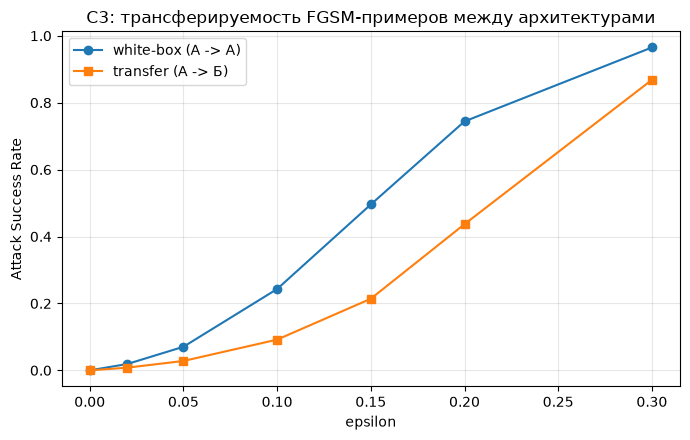

eps=0.00: white-box ASR=0.0000, transfer ASR=0.0000 (0% от white-box)
eps=0.02: white-box ASR=0.0189, transfer ASR=0.0080 (42% от white-box)
eps=0.05: white-box ASR=0.0704, transfer ASR=0.0281 (40% от white-box)
eps=0.10: white-box ASR=0.2431, transfer ASR=0.0918 (38% от white-box)
eps=0.15: white-box ASR=0.4958, transfer ASR=0.2140 (43% от white-box)
eps=0.20: white-box ASR=0.7441, transfer ASR=0.4369 (59% от white-box)
eps=0.30: white-box ASR=0.9650, transfer ASR=0.8681 (90% от white-box)


In [16]:
# С3. Трансферируемость adversarial-примеров между архитектурами
class AltCNN(nn.Module):
    """Модель Б: другая архитектура — 1 conv-слой с 32 каналами 5x5 + MLP."""

    def __init__(self, n_classes=10):
        super().__init__()
        self.conv = nn.Conv2d(1, 32, kernel_size=5)      # 24x24x32
        self.pool = nn.MaxPool2d(2)                      # 12x12x32
        self.fc1 = nn.Linear(32 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


model_b = AltCNN().to(device)
opt_b = torch.optim.Adam(model_b.parameters(), lr=1e-3)
model_b.train()
for epoch in range(N_EPOCHS):
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt_b.zero_grad()
        criterion(model_b(xb), yb).backward()
        opt_b.step()
acc_b = clean_accuracy_fn(model_b, test_loader)
print(f"Модель Б (AltCNN) обучена, clean accuracy: {acc_b:.4f}")


def evaluate_transfer(model_src, model_tgt, loader, epsilon, criterion_, n_batches=10):
    """Атаки строятся на model_src (white-box), проверяются на model_tgt (black-box)."""
    model_src.eval(); model_tgt.eval()
    success = total = 0
    for i, (xb, yb) in enumerate(loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        x_adv = fgsm_attack(model_src, xb, yb, epsilon, criterion_)
        with torch.no_grad():
            pred_src = model_src(x_adv).argmax(1)
            pred_tgt = model_tgt(x_adv).argmax(1)
        base_tgt = model_tgt(xb).argmax(1)
        success += ((base_tgt == yb) & (pred_tgt != yb)).sum().item()
        total += (base_tgt == yb).sum().item()
    return success / total


transfer_asrs = []
whitebox_asrs = []
for e in epsilons:
    whitebox_asrs.append(evaluate_transfer(model, model, test_loader, e, criterion))
    transfer_asrs.append(evaluate_transfer(model, model_b, test_loader, e, criterion))

plt.figure(figsize=(7, 4.5))
plt.plot(epsilons, whitebox_asrs, marker='o', label='white-box (A -> A)')
plt.plot(epsilons, transfer_asrs, marker='s', label='transfer (A -> Б)')
plt.xlabel('epsilon'); plt.ylabel('Attack Success Rate')
plt.title('С3: трансферируемость FGSM-примеров между архитектурами')
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

for e, w, t in zip(epsilons, whitebox_asrs, transfer_asrs):
    print(f"eps={e:.2f}: white-box ASR={w:.4f}, transfer ASR={t:.4f} "
          f"({t/max(w,1e-9):.0%} от white-box)")

**Вывод по С3 (трансферируемость).** Adversarial-примеры, построенные white-box на модели А (MyCNN, 2 conv-слоя), успешно обманывают архитектурно другую модель Б (AltCNN, 1 conv 5×5 + MLP), обученную независимо: transfer ASR составляет 38–43% от white-box ASR при средних $\epsilon$ (0.05–0.15) и **до 90% при $\epsilon=0.3$** (86.8% абсолютных). Это подтверждает наблюдение Szegedy et al. / Goodfellow et al.: adversarial-примеры — не артефакт конкретной сети, а свойство пространства решений, порождённое общей линейной структурой глубоких моделей, обученных на одних и тех же данных. Практическое следствие для безопасности: атакующему **не нужен доступ к весам целевой модели** — достаточно обучить собственный surrogate на аналогичных данных (black-box сценарий), что делает «секретность архитектуры» несостоятельной мерой защиты (см. лекцию 6 о transfer-атаках).

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: расчёт RF, реализация FGSM, график ASR(ε), сравнение с adversarial training.
